# SVD Image Compression
Below, we use the SVD Algorithm to perform image compression.

SVD is a way to factor any matrix 
$A$ into three simpler matrices that reveal its most important structure:

$A = U \Sigma V^T$

where:
- A is your original matrix (an image),
- U contains the left singular vectors (orthonormal columns),
- $\Sigma$ is a diagonal matrix of singular values (strength of each component),
- $V$ contains the right singular vectors.

Steps:
1. A can be any real $m \times n$ matrix 

2. Compute the U, $\Sigma$ and V

SVD finds orthonormal bases for the row space and column space of A.
U describes directions in the rows of A,
V describes directions in the columns of A,
$\Sigma$ holds non-negative singular values $\sigma_1, \sigma_2 ... 0$ which tell us the contribution of each direction.

3. Interpret decomposition

Each term in the sum A $\approx$ $\sum\limits_{i=1}^k \sigma_i u_i v_i^{T}$ represents an approximation — a simple pattern of variation. Larger singular values correspond to more important patterns; small singular values contribute less information.

4. Truncate for compression or dimensionality reduction

By keeping only the top 
$k$ singular values (and corresponding vectors), you can approximate $A$ as $A_k = U_k \Sigma_k V^T$

This effectively does the following: 
- reduces storage from $m \times n$ to just the top k components
- captures the most significant patterns
- discards noise or low-variance information

5. Reconstruct your matrix

Multiply the truncated $U_k \Sigma_k V^T$ back together to get an approximate matrix $A_k$ that is similar to your original but with reduced complexity.

## Data Preprocessing

### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

### Load Image

In [2]:
# Load your local image
original_img = io.imread("model.png") / 255.0  # normalize to [0, 1]
original_img

array([[[0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.      

### Cleanup Image
Remove the alpha channel

In [3]:
# Remove alpha channel
original_img = original_img[:, :, :3]

## Apply SVD

In [4]:
# Prepare reconstructed image with same shape
compressed_img = np.zeros_like(original_img)

# Choose number of singular values to keep
k = 50

# Apply SVD compression separately on each channel
for ch in range(3):  # R, G, B
    U, S, VT = np.linalg.svd(original_img[:, :, ch], full_matrices=False)
    compressed_channel = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    compressed_img[:, :, ch] = np.clip(compressed_channel, 0, 1)  # keep values valid

## Results
Plot the original and compressed images to compare results
As we can see below, by having a k of only 50, our image maintains its most pertinent features, while having a much smaller size.

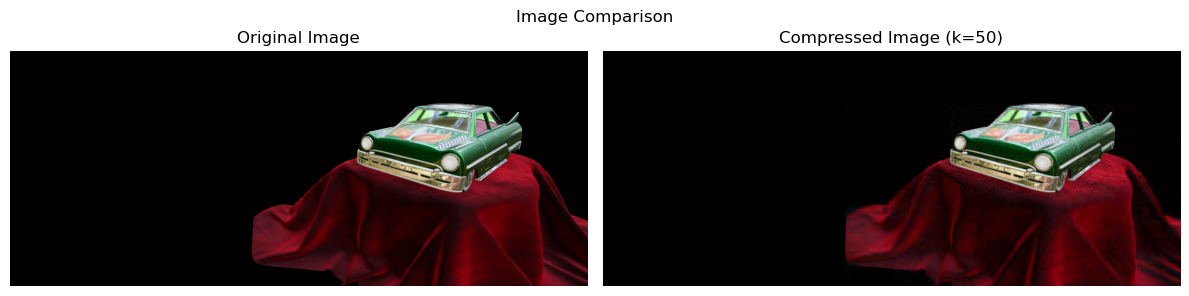

In [5]:
# Plot original and compressed images
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(compressed_img)
axes[1].set_title(f"Compressed Image (k={k})")
axes[1].axis('off')

fig.suptitle("Image Comparison")
plt.tight_layout()

plt.show()


### Changing image as k changes
Here we can see exactly how the images change as we increase the number of k's

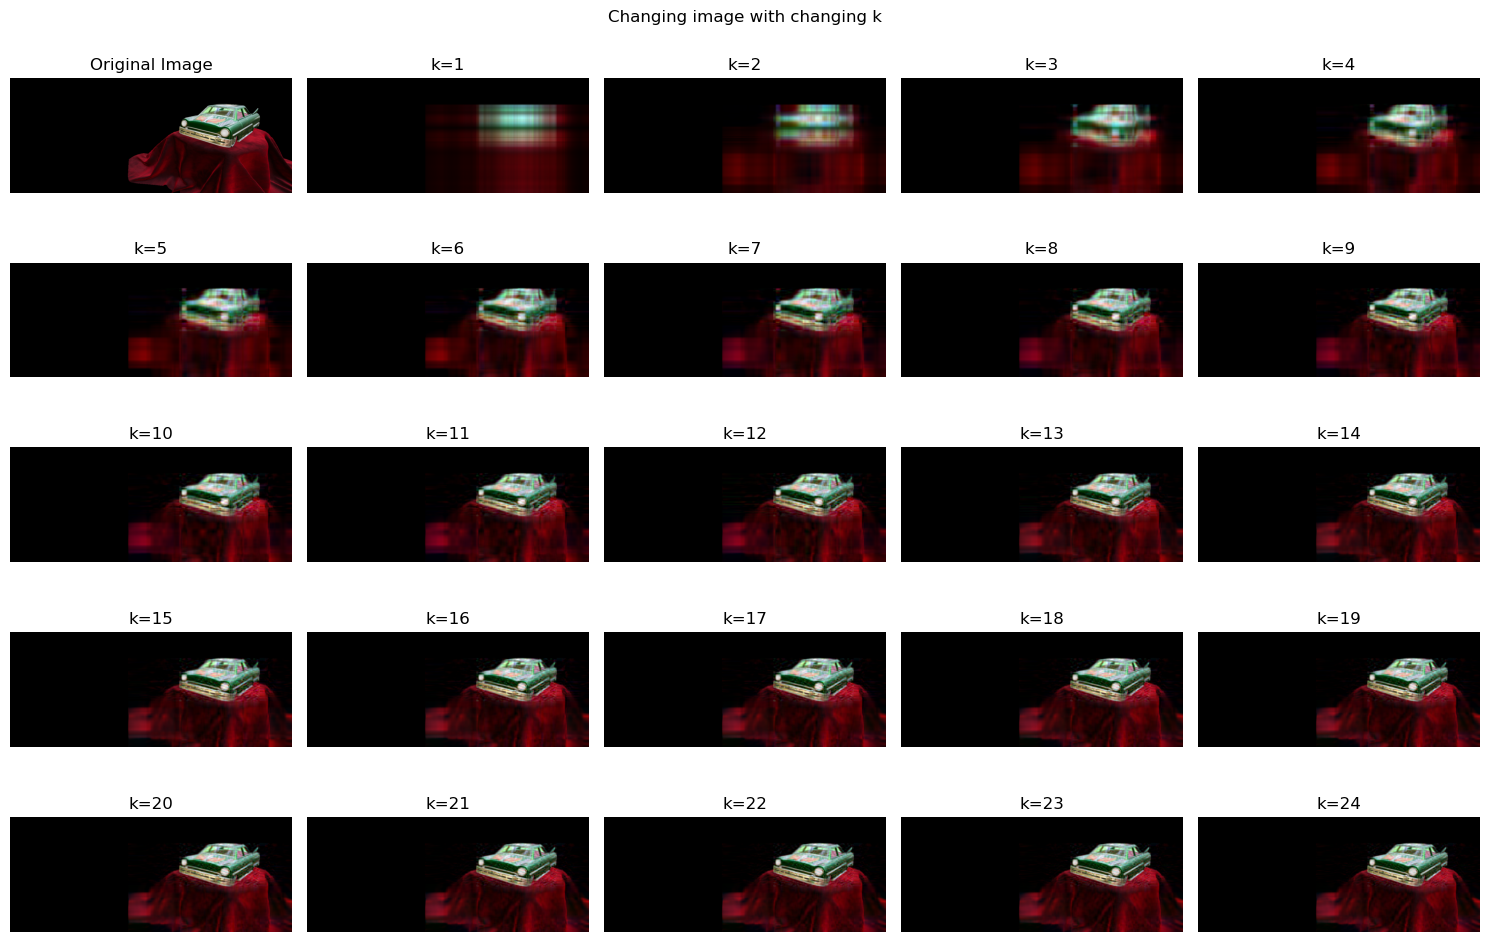

In [6]:
k = 25  # number of subplots (including original image)

fig, axes = plt.subplots(5, 5, figsize=(15, 10))
axes = axes.flatten()  # make axes 1D array for easy indexing

# Display the original image in the first subplot
axes[0].imshow(original_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Create compressed versions with increasing k
for i in range(1, k):
    compressed_img = np.zeros_like(original_img)
    
    # Apply SVD compression separately on each channel
    for ch in range(3):  # R, G, B
        U, S, VT = np.linalg.svd(original_img[:, :, ch], full_matrices=False)
        compressed_channel = U[:, :i] @ np.diag(S[:i]) @ VT[:i, :]
        compressed_img[:, :, ch] = np.clip(compressed_channel, 0, 1)
    
    axes[i].imshow(compressed_img)
    axes[i].set_title(f"k={i}")
    axes[i].axis('off')

fig.suptitle("Changing image with changing k")
plt.tight_layout()
plt.show()
